# ADCNN evaluation — catalog-based

Pure analysis of the **pre-generated detection catalogs** (`Evaluation/catalogs/`, from
`make_eval_catalogs`: deployed segmentation model + focal cutout CNN, `gate_pmax=0.10`, CNN cut at `CNN_DEFAULT_THR`). No NN
inference, no training, no test-set threshold tuning. Each σ set: match catalog↔truth
(any-pixel-overlap, fixed `tol_px`, all-trails denominator) → NN object metrics + FP, the
NN vs LSST-stack vs combined comparison, completeness, parameter recovery; plus the cross-σ
completeness overlay (5σ / 5σ+NN / 4σ / 3σ) at the end. LSST-stack recall+FP read from the
stack footprints (`real_labels`) — fast, no inference. (Pixelwise confusion + score sweep omitted.)

In [1]:
import sys, os
from pathlib import Path
import numpy as np, pandas as pd, h5py, matplotlib.pyplot as plt
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'ADCNN').is_dir()), Path.cwd())
sys.path.insert(0, str(REPO))
import ADCNN.evaluation.detection as evals
from ADCNN.evaluation.catalog_match import evaluate_catalog, match_pairs
from ADCNN.inference.cnn_postproc import CNN_DEFAULT_THR

# Env-driven (the eval SLURM script sets these). Works for BOTH the build-once/detect-many synthetic
# `test` set (one h5, NN inference once, LSST-stack baseline labelled per sigma) AND a single-stack
# set such as the real `test_real` (one stack_detection / real_labels).
CATALOGS  = Path(os.environ.get('ADCNN_EVAL_CATALOGS', str(REPO/'Evaluation/catalogs')))
DATA      = Path(os.environ.get('ADCNN_EVAL_DATA',     str(REPO/'DATA_DIFFIM')))
TEST_SET  = os.environ.get('ADCNN_EVAL_TEST', 'test')
SIGMAS    = [float(s) for s in os.environ.get('ADCNN_EVAL_SIGMAS', '5,4,3').split(',')]
SEG_MODEL = os.environ.get('ADCNN_EVAL_SEG', str(REPO/'models/segmentation_model.pt'))
CNN_MODEL = os.environ.get('ADCNN_EVAL_CNN', str(REPO/'models/cnn_postproc.pt'))
TOL_PX = 20.0

def _tag(s):
    s = float(s); return str(int(s)) if s.is_integer() else str(s)

def _paths(name):
    """(h5, truth_csv): flat <DATA>/<name>.{h5,csv} or subdir <DATA>/<name>/test.{h5,csv}."""
    if (DATA/f'{name}.h5').exists():
        return DATA/f'{name}.h5', DATA/f'{name}.csv'
    return DATA/name/'test.h5', DATA/name/'test.csv'

H5, TRUTH_CSV = _paths(TEST_SET); DET_CSV = CATALOGS/f'{TEST_SET}_detections.csv'

# Stack-baseline configs (label, truth stack-detection column, h5 real_labels dataset): one per sigma
# for a multi-sigma set, else a single `stack_detection` / `real_labels`.
_tcols = pd.read_csv(TRUTH_CSV, nrows=0).columns
_persig = [c for c in _tcols if c.startswith('stack_detection_') and c.endswith('sigma')]
if _persig:
    CONFIGS = [(f'{_tag(s)} sigma', f'stack_detection_{_tag(s)}sigma', f'real_labels_{_tag(s)}sigma') for s in SIGMAS]
else:
    CONFIGS = [('LSST stack', 'stack_detection', 'real_labels')]
print(f'test={TEST_SET} | configs={[c[0] for c in CONFIGS]} | seg={Path(SEG_MODEL).name} | CNN cut={CNN_DEFAULT_THR} | tol={TOL_PX}px')
print(f'  h5={H5}\n  truth={TRUTH_CSV}\n  detections={DET_CSV}')

_FP = {}
def stack_fp_count(fp_key):
    if fp_key not in _FP:
        with h5py.File(H5,'r') as f:
            rl=f[fp_key]; _FP[fp_key]=int(sum(int(rl[i].max()) for i in range(rl.shape[0])))
    return _FP[fp_key]

_EVAL = {}
def evaluate_once():
    """ONE NN evaluation (sigma-/config-independent). Returns (counts, t, pairs, cat); t carries
    nn_detected, every config's stack-detection bool, and stack_detection defaulted to CONFIGS[0]."""
    if not _EVAL:
        cat=pd.read_csv(DET_CSV); truth=pd.read_csv(TRUTH_CSV)
        counts,t=evaluate_catalog(cat,truth,tol_px=TOL_PX)
        for _lab, sc, _fp in CONFIGS:
            t[sc]=t[sc].astype(bool)
        t['stack_detection']=t[CONFIGS[0][1]]   # default baseline = first config
        _EVAL['v']=(counts,t,match_pairs(cat,truth,tol_px=TOL_PX),cat)
    return _EVAL['v']

def show_confusion(counts,title):
    evals.print_confusion_matrix({'TN':pd.NA,'FP':counts['FP'],'FN':counts['FN'],'TP':counts['TP']},title=title)

def compare_methods(label, stack_col, fp_key, counts, t):
    nn=t['nn_detected'].astype(bool); st=t[stack_col].astype(bool); comb=nn|st
    npan=t['image_id'].nunique(); sfp=stack_fp_count(fp_key)
    print(f'\n[{label}] NN vs LSST-stack vs combined (n={len(t)} trails, {npan} panels):')
    print(f'  LSST stack : recall={st.mean():.3f} ({int(st.sum())})   FP={sfp} ({sfp/npan:.1f}/panel)')
    print(f'  seg+CNN NN : recall={nn.mean():.3f} ({int(nn.sum())})   FP={counts["FP"]} ({counts["fp_per_panel"]:.1f}/panel)')
    print(f'  combined   : recall={comb.mean():.3f} ({int(comb.sum())})   NN recovers {int((nn&~st).sum())} stack-missed')

def completeness_overlay(cols, labels, field, bins=12, xlim=None, title=None):
    """Overlay completeness(field) for several boolean 'detected' masks aligned to the truth table t."""
    _,t,_,_=evaluate_once()
    edges=(np.linspace(xlim[0],xlim[1],bins+1) if xlim is not None
           else np.histogram_bin_edges(t[field].to_numpy()[np.isfinite(t[field])],bins=bins))
    fig, ax = plt.subplots(figsize=(7,4.5))
    for lab, det in zip(labels, cols):
        all_i=np.histogram(t[field],bins=edges)[0]; det_i=np.histogram(t[field][det.values],bins=edges)[0]
        ax.stairs(det_i/np.maximum(all_i,1), edges, label=lab)
    ax.set_xlabel(field.replace('_',' ')); ax.set_ylabel('Completeness'); ax.set_title(title or f'Completeness vs {field}'); ax.legend(); ax.grid(True,alpha=0.3); plt.show()


test=test | configs=['5 sigma', '4 sigma', '3 sigma'] | seg=seg_v2_segmentation_scripted.pt | CNN cut=0.6 | tol=20.0px
  h5=/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/DATA/test.h5
  truth=/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/DATA/test.csv
  detections=/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/Evaluation/catalogs_seg_v2/test_detections.csv


## Network architecture

Schematics of the two-stage ADCNN detector, generated **directly from the deployed weights** (`models/segmentation_model.pt`, `models/cnn_postproc.pt`): layer types, channel counts and spatial resolutions are read back by reconstructing each module from its checkpoint and forward-tracing it, so the figures stay correct if the architecture changes. Rendered by `ADCNN.evaluation.architecture`; vector PDFs + 300-dpi PNGs are written to `Evaluation/figures/`. Five standalone figures:

1. **U-Net-ResSE backbone + output head** — encoder/decoder with per-stage C×H×W and skips; the 1×1-conv head emits 3 raw channels that split into a segmentation branch (raw seg logit → +α·Hough → sigmoid ⇒ detection probability) and an orientation branch (→ tanh ⇒ sin 2β, cos 2β).
2. **Residual squeeze-excite block** (the repeated unit).
3. **Hough line-aggregator.**
4. **Focal-loss cutout-CNN false-positive filter.**
5. **End-to-end discovery pipeline.**

[architecture] seg: in_ch=3 widths=[24, 48, 96, 192, 384] out_ch=3 levels=5 hough_alpha=0.052
[architecture] filter-CNN figure skipped: AttributeError: 'Net' object has no attribute 'f'


[architecture] saved 4 figures to /sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/Evaluation/figures/ (300-dpi PNG + vector PDF)


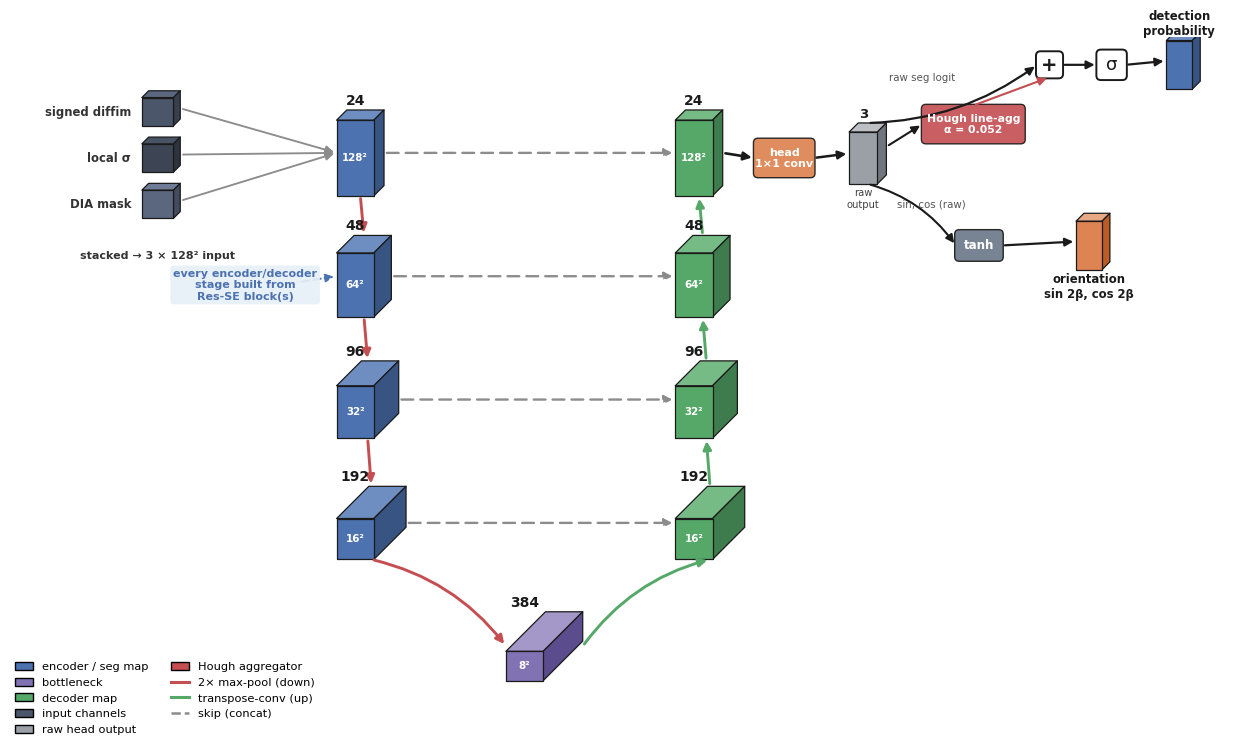

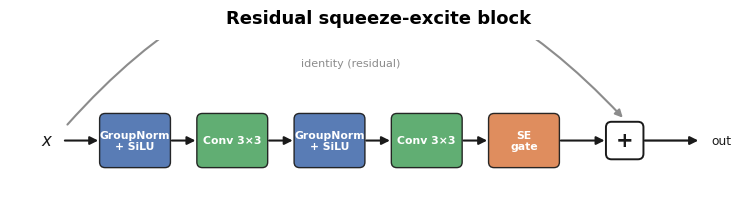

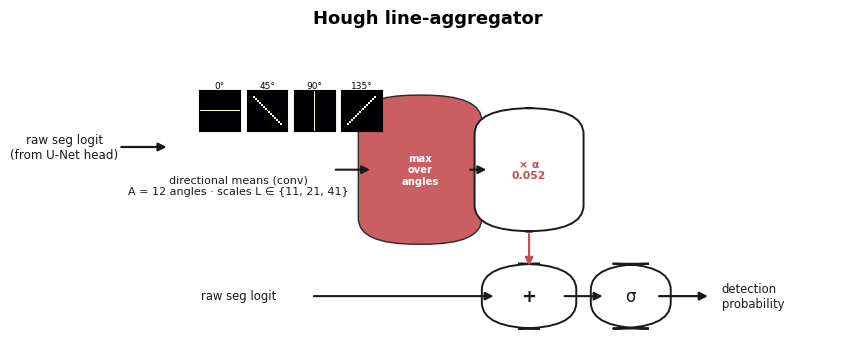

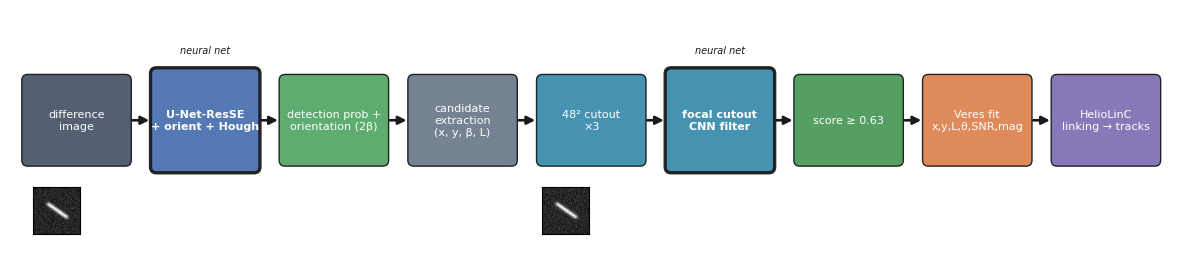

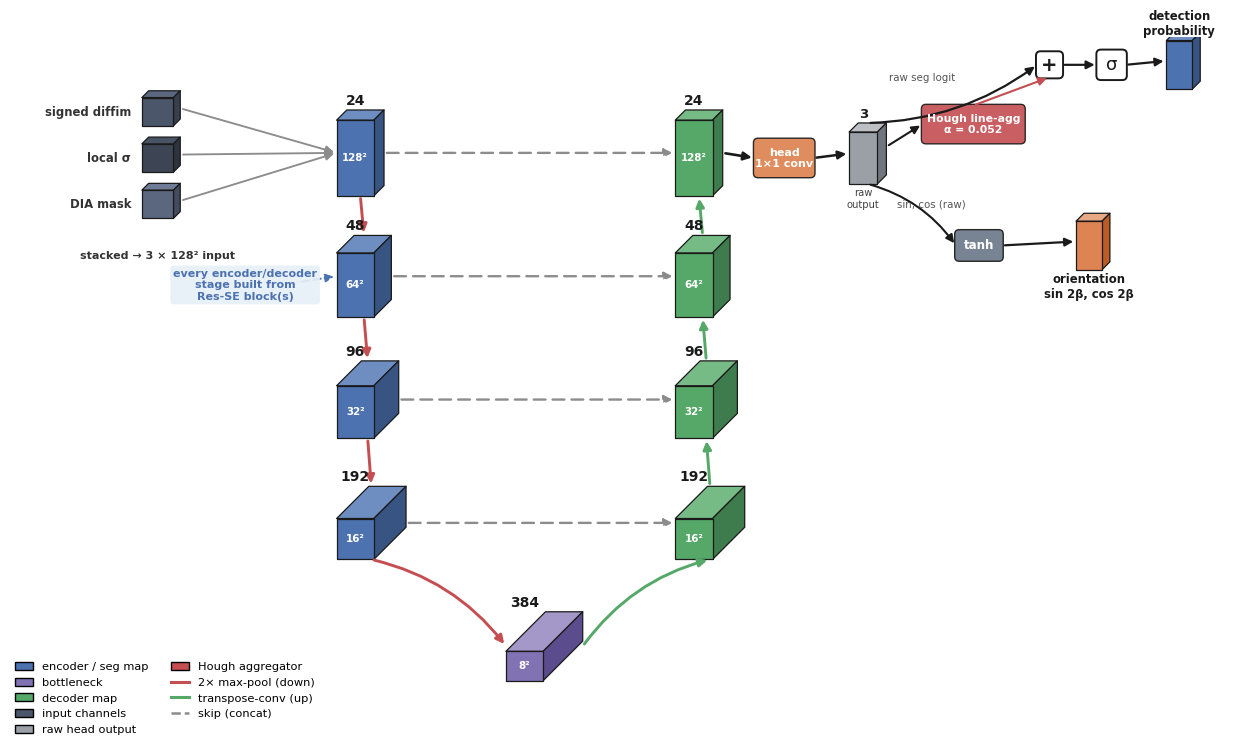

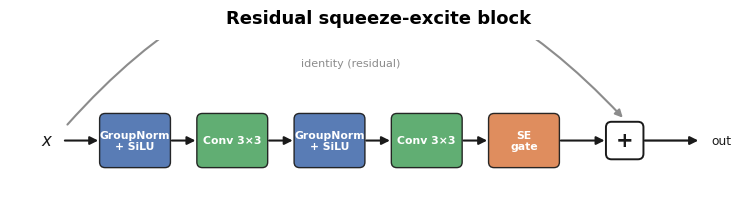

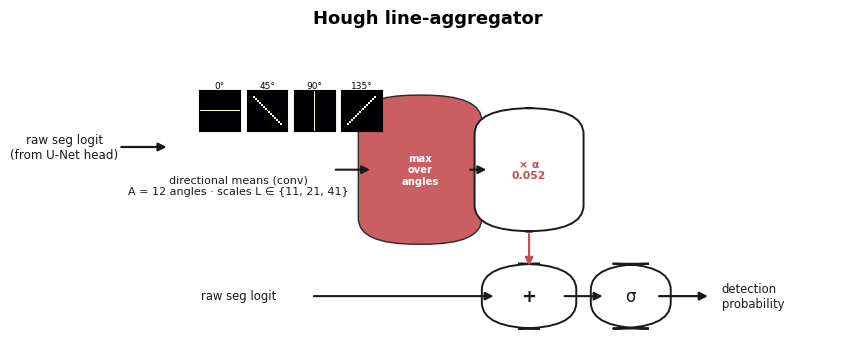

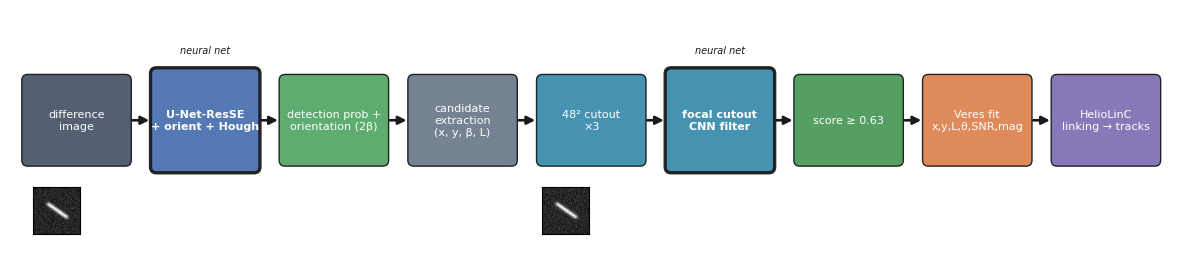

In [2]:
# Paper-quality network schematics, introspected from the evaluated weights
# (see ADCNN/evaluation/architecture.py). Re-run to regenerate Evaluation/figures/arch_*.{png,pdf}.
%matplotlib inline
from ADCNN.evaluation.architecture import make_architecture_figures
figs = make_architecture_figures(seg_path=SEG_MODEL, cnn_path=CNN_MODEL,
                                 outdir=str(REPO/'Evaluation/figures'), show=True)
for _name, _f in figs.items():
    display(_f)


## NN evaluation (sigma-independent) + hero


test + NN - object-level (NN)
F1 Score: 0.3139, F2 Score: 0.4979
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               18035
Actual Positive                 972                4348

segmentation model + CNN: recall=0.817 (4348/5320)  FP=18035 (67.80/panel) over 266 panels


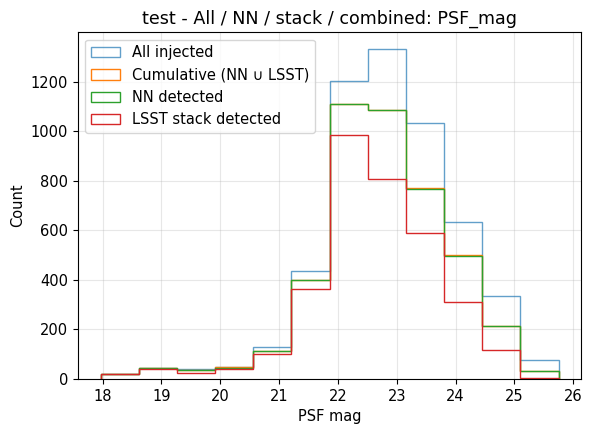

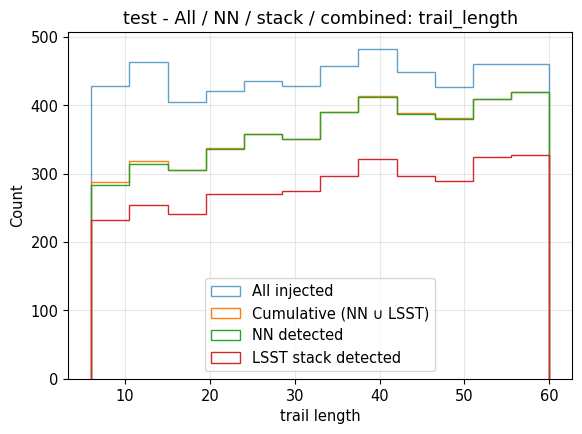

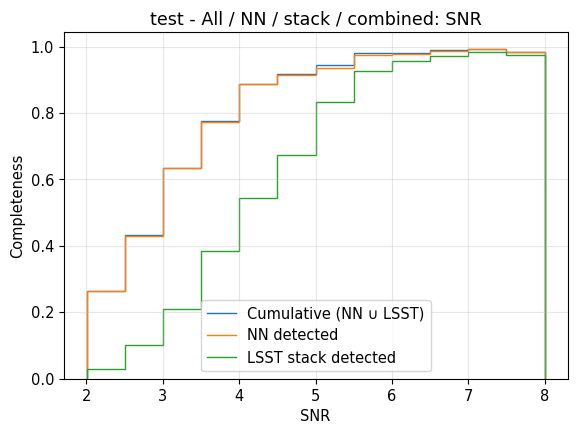

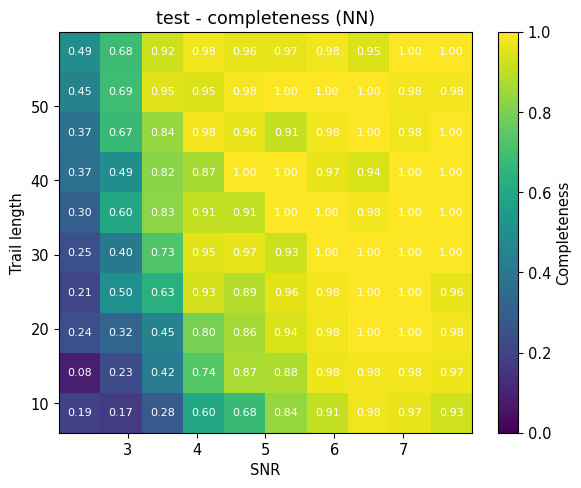

In [3]:
# NN evaluation on the test set (sigma-INDEPENDENT: the NN does not depend on the stack sigma -> one
# inference). Histograms also show the LSST stack at the deepest sigma for reference.
counts, t, pairs, cat = evaluate_once()
show_confusion(counts, f'{TEST_SET} + NN - object-level (NN)')
nn=t['nn_detected'].astype(bool); npan=t['image_id'].nunique()
print(f'segmentation model + CNN: recall={nn.mean():.3f} ({int(nn.sum())}/{len(t)})  '
      f'FP={counts["FP"]} ({counts["fp_per_panel"]:.2f}/panel) over {npan} panels')
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(t, field, bins=12, title=f'{TEST_SET} - All / NN / stack / combined: {field}', **kw); plt.show()
evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title=f'{TEST_SET} - completeness (NN)'); plt.show()


### Parameter recovery — measured vs true (matched trails): x, y, beta, length

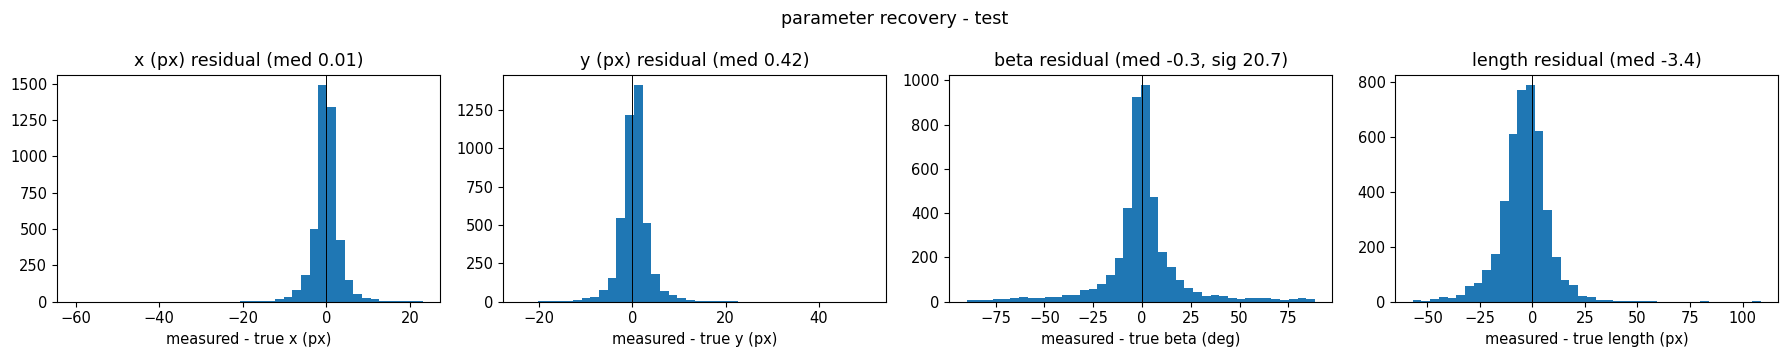

In [4]:
# Parameter recovery (measured vs true) for matched trails: x, y, beta, length residuals.
_, _, pairs, _ = evaluate_once()
fig, ax = plt.subplots(1, 4, figsize=(18,3.6))
for k,(col,mcol,lab) in enumerate([('x','meas_x','x (px)'),('y','meas_y','y (px)')]):
    d=pairs[mcol]-pairs[col]; ax[k].hist(d,bins=40); ax[k].axvline(0,c='k',lw=.7); ax[k].set_xlabel(f'measured - true {lab}'); ax[k].set_title(f'{lab} residual (med {d.median():.2f})')
db=((pairs.meas_beta-pairs.beta+90)%180)-90; ax[2].hist(db,bins=40); ax[2].axvline(0,c='k',lw=.7); ax[2].set_xlabel('measured - true beta (deg)'); ax[2].set_title(f'beta residual (med {db.median():.1f}, sig {db.std():.1f})')
dl=pairs.meas_length-pairs.trail_length; ax[3].hist(dl,bins=40); ax[3].axvline(0,c='k',lw=.7); ax[3].set_xlabel('measured - true length (px)'); ax[3].set_title(f'length residual (med {dl.median():.1f})')
plt.suptitle(f'parameter recovery - {TEST_SET}'); plt.tight_layout(); plt.show()


## LSST-stack baseline per config (NN vs stack)


5 sigma



[5 sigma] NN vs LSST-stack vs combined (n=5320 trails, 266 panels):
  LSST stack : recall=0.638 (3396)   FP=16010 (60.2/panel)
  seg+CNN NN : recall=0.817 (4348)   FP=18035 (67.8/panel)
  combined   : recall=0.820 (4361)   NN recovers 965 stack-missed


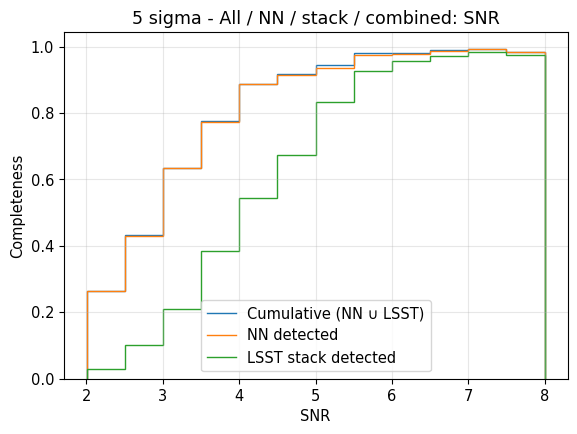

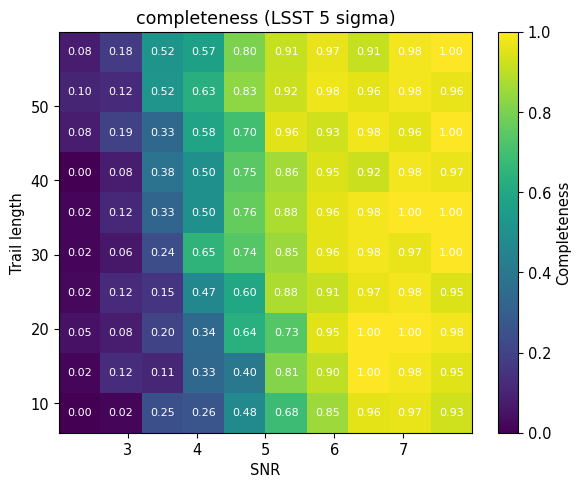

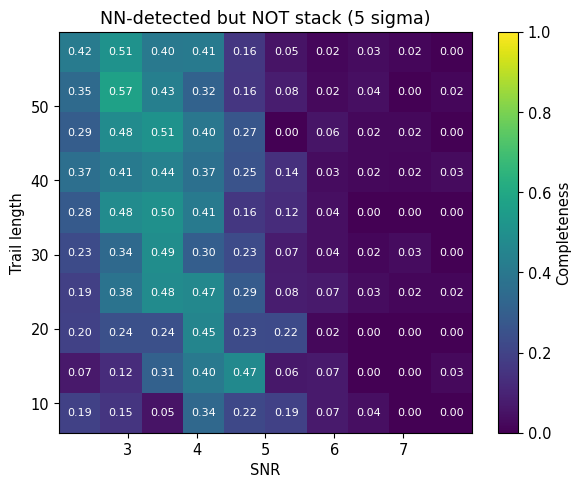

4 sigma



[4 sigma] NN vs LSST-stack vs combined (n=5320 trails, 266 panels):
  LSST stack : recall=0.802 (4268)   FP=75040 (282.1/panel)
  seg+CNN NN : recall=0.817 (4348)   FP=18035 (67.8/panel)
  combined   : recall=0.845 (4493)   NN recovers 225 stack-missed


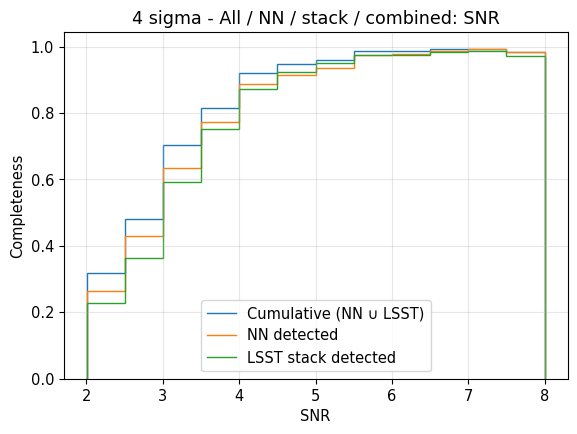

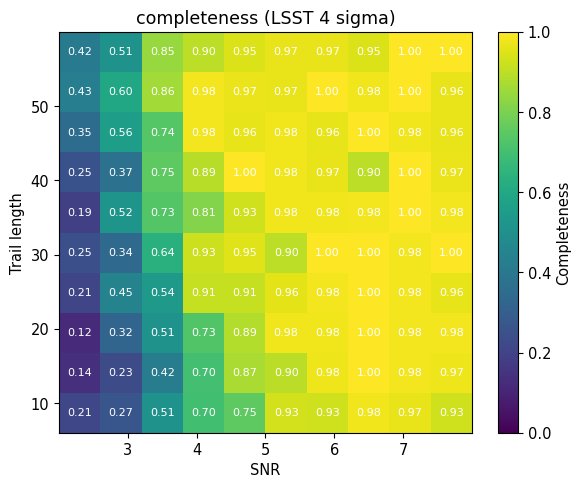

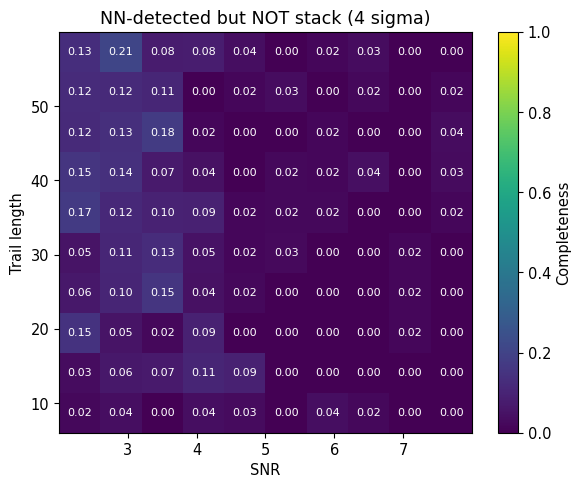

3 sigma



[3 sigma] NN vs LSST-stack vs combined (n=5320 trails, 266 panels):
  LSST stack : recall=0.910 (4840)   FP=1049116 (3944.0/panel)
  seg+CNN NN : recall=0.817 (4348)   FP=18035 (67.8/panel)
  combined   : recall=0.937 (4985)   NN recovers 145 stack-missed


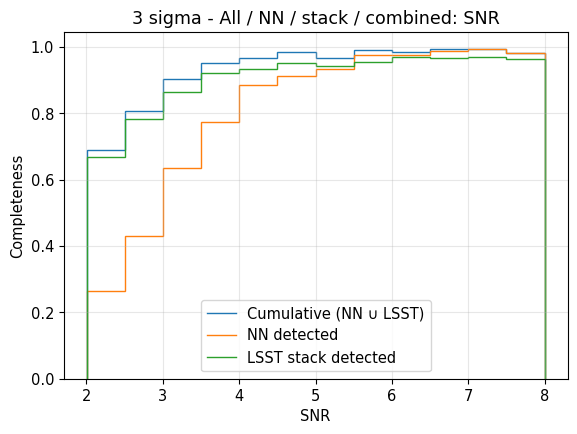

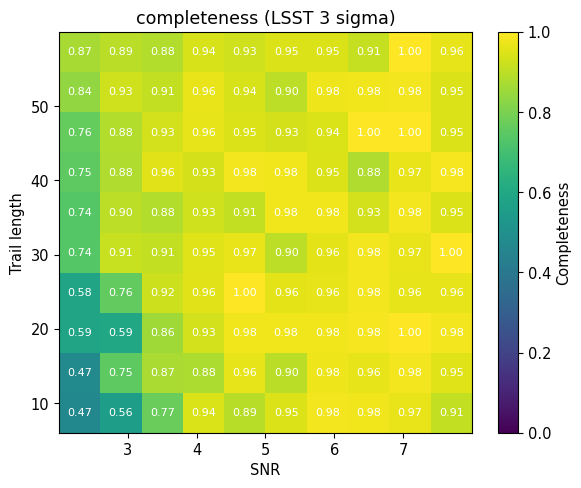

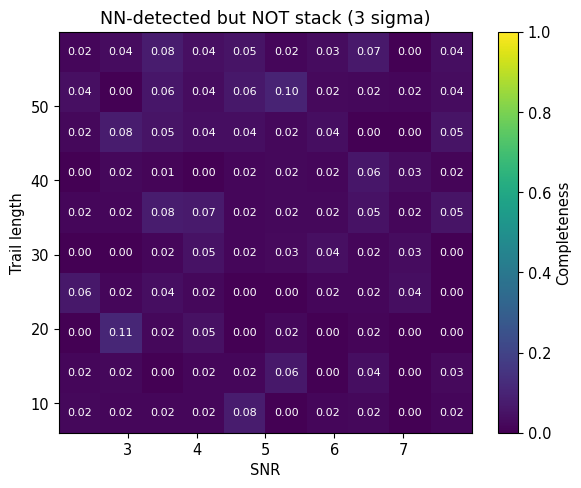

In [5]:
# LSST-stack baseline per config (the NN is identical; only the stack detection changes).
counts, t, _, _ = evaluate_once()
for label, stack_col, fp_key in CONFIGS:
    print('='*70); print(label)
    compare_methods(label, stack_col, fp_key, counts, t)
    ts = t.copy(); ts['stack_detection'] = t[stack_col]
    evals.plot_detect_hist(ts, 'SNR', bins=12, xlim=[0,10], density=True,
                           title=f'{label} - All / NN / stack / combined: SNR'); plt.show()
    evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, detected=t[stack_col].values,
                               title=f'completeness (LSST {label})'); plt.show()
    evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10,
                               detected=(~t[stack_col].values & t['nn_detected'].values.astype(bool)),
                               title=f'NN-detected but NOT stack ({label})'); plt.show()


### (per-sigma completeness, continued)


In [6]:
# (per-sigma stack comparison handled by the loop above)


## Combined — cross-σ completeness comparison (5σ vs 5σ+NN vs 4σ vs 3σ)

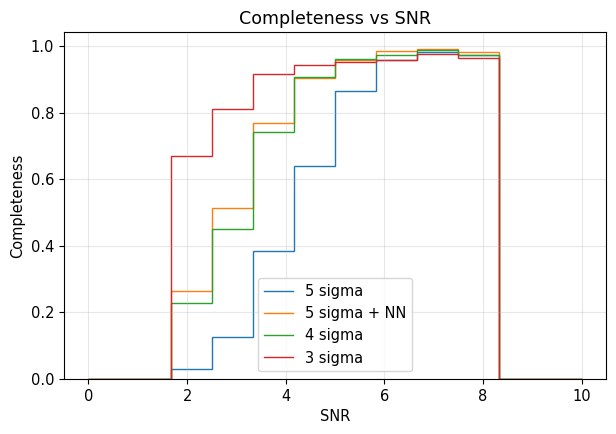

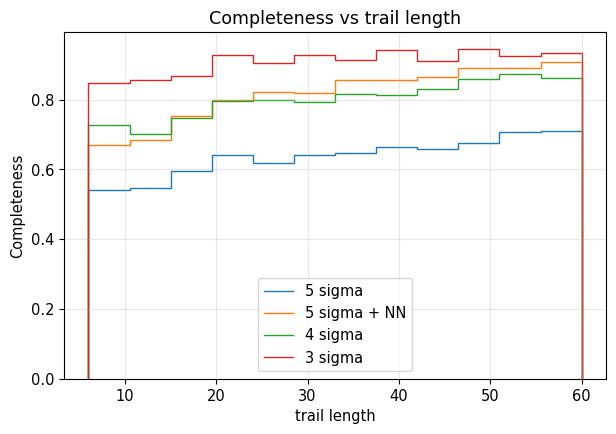

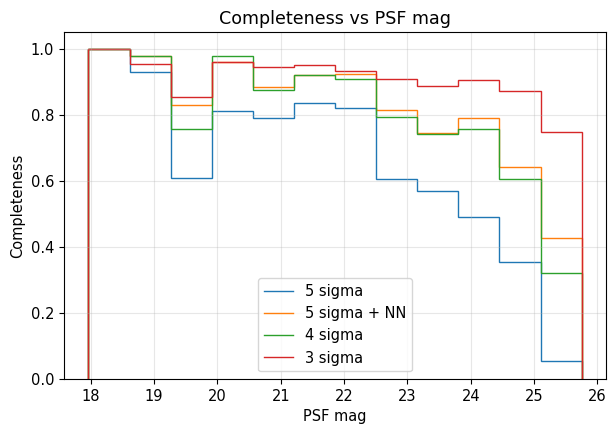

In [7]:
# Cross-config completeness overlay: first stack config, that config + NN, then the rest.
_, t, _, _ = evaluate_once()
nn=t['nn_detected'].astype(bool); c0=CONFIGS[0]
cols=[t[c0[1]].astype(bool), t[c0[1]].astype(bool)|nn]; labels=[c0[0], f'{c0[0]} + NN']
for label, sc, _fp in CONFIGS[1:]:
    cols.append(t[sc].astype(bool)); labels.append(label)
completeness_overlay(cols, labels, 'SNR', xlim=[0,10], title='Completeness vs SNR')
completeness_overlay(cols, labels, 'trail_length', title='Completeness vs trail length')
completeness_overlay(cols, labels, 'PSF_mag', title='Completeness vs PSF mag')


## Final summary — TP / FP / FN (LSST stack at 3σ/4σ/5σ vs 5σ + NN combined)

In [8]:
# Final table: TP / FP / FN per config (LSST stack per config; "+ NN" = CROSS-DEDUP'D UNION of
# the stack and seg+CNN catalogs -- a source both detectors fire on within TOL_PX is counted
# once, attributed to the stack; each catalog's own internal clusters are preserved. Matches
# the deployed combined detector. Earlier table used a sum-FP that double-counted overlaps,
# then a within-panel-dedup that wrongly collapsed within-stack clusters too.)
from ADCNN.evaluation.catalog_match import stack_sigma_catalog, dedup_cross_catalog
counts, t, _, cat = evaluate_once()
ids = sorted(t['image_id'].unique()); npan = t['image_id'].nunique()
nn_cat = cat[['image_id','x','y','beta','length']].copy()
def _sigma_from_fp_key(fk):
    s = fk.replace('real_labels','').strip('_').replace('sigma','')
    return int(float(s)) if s else 5
rows = []
for label, sc, fp_key in CONFIGS:
    sigma = _sigma_from_fp_key(fp_key)
    st_cat = stack_sigma_catalog(H5, TRUTH_CSV, ids, sigma=sigma)
    union  = dedup_cross_catalog(st_cat, nn_cat, tol_px=TOL_PX)
    sm, _ = evaluate_catalog(st_cat, TRUTH_CSV, tol_px=TOL_PX, n_panels=npan)
    um, _ = evaluate_catalog(union,  TRUTH_CSV, tol_px=TOL_PX, n_panels=npan)
    rows.append({'config': label,         'TP': sm['TP'], 'FP': sm['FP'], 'FN': sm['FN'], 'FP/panel': round(sm['fp_per_panel'],2)})
    rows.append({'config': label+' + NN', 'TP': um['TP'], 'FP': um['FP'], 'FN': um['FN'], 'FP/panel': round(um['fp_per_panel'],2)})
print(pd.DataFrame(rows)[['config','TP','FP','FN','FP/panel']].to_string(index=False))


      config   TP      FP   FN  FP/panel
     5 sigma 3396   16006 1924     60.17
5 sigma + NN 4360   33980  960    127.74
     4 sigma 4318   74830 1002    281.32
4 sigma + NN 4525   83977  795    315.70
     3 sigma 5050 1045754  270   3931.41
3 sigma + NN 5097 1048361  223   3941.21
